###importing libraries


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


In [ ]:
df= pd.read_csv("/content/Internshala_scraped_jobs.csv")

In [ ]:
df.head()

,JOB Role,Company,Salary,Location
0,Associate Telecaller,HireWala,"₹ 3,00,000 - 5,00,000",Mumbai
1,Business Development Executive,METGUARD,"₹ 3,02,000 - 4,25,000",Kolkata
2,Graphic Designer,Stag International,"₹ 4,20,000 - 4,80,000",Meerut
3,Electrical Engineer,Varistor Solar,"₹ 3,80,000 - 4,40,000",Rajasthan
4,Ecommerce Executive,Stag International,"₹ 3,00,000 - 3,60,000",Meerut


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8388 entries, 0 to 8387
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   JOB Role  8388 non-null   object
 1   Company   8388 non-null   object
 2   Salary    8075 non-null   object
 3   Location  7919 non-null   object
dtypes: object(4)
memory usage: 262.3+ KB


##converting the data into there data types

In [ ]:
import re


In [ ]:

# --------------------
# 1. Clean Salary Column
# --------------------
def clean_salary(s):
    if pd.isna(s) or "Unpaid" in str(s):
        return (0, 0, 0)  # for unpaid or missing salaries

    # Remove extra text and symbols
    s = s.replace("₹", "").replace(",", "").replace("/year", "").strip()

    # Match salary ranges
    match = re.findall(r'\d+', s)
    if len(match) == 2:
        min_salary, max_salary = int(match[0]), int(match[1])
        avg_salary = (min_salary + max_salary) // 2
        return (min_salary, max_salary, avg_salary)
    elif len(match) == 1:
        val = int(match[0])
        return (val, val, val)
    else:
        return (0, 0, 0)

# Apply cleaning function
df[["MinSalary", "MaxSalary", "AvgSalary"]] = df["Salary"].apply(lambda x: pd.Series(clean_salary(x)))

# --------------------
# 2. Clean Location Column
# --------------------
def clean_location(loc):
    if pd.isna(loc):
        return "Unknown"
    return loc.strip().split(",")[0]  # take only first location if multiple

df["Location"] = df["Location"].apply(clean_location)

# --------------------
# 3. Basic Cleaning for Role & Company
# --------------------
df["JOB Role"] = df["JOB Role"].str.strip().str.title()
df["Company"] = df["Company"].str.strip()

# --------------------
# Save Cleaned Data
# --------------------
df.to_csv("Cleaned_Internshala_Jobs.csv", index=False)

print(df.head(10))
print(df.info())


                         JOB Role             Company                 Salary  \
0            Associate Telecaller            HireWala  ₹ 3,00,000 - 5,00,000   
1  Business Development Executive            METGUARD  ₹ 3,02,000 - 4,25,000   
2                Graphic Designer  Stag International  ₹ 4,20,000 - 4,80,000   
3             Electrical Engineer      Varistor Solar  ₹ 3,80,000 - 4,40,000   
4             Ecommerce Executive  Stag International  ₹ 3,00,000 - 3,60,000   
5                Apparel Designer  Stag International  ₹ 2,60,000 - 2,80,000   
6       Video & Animation Creator         Startupcfos  ₹ 2,00,000 - 3,00,000   
7               Creative Designer             GetREAL             ₹ 3,00,000   
8                    Video Editor           Dreamfoot  ₹ 2,00,000 - 3,00,000   
9                    Psychologist        Kapable.club  ₹ 4,00,000 - 6,00,000   

                                            Location  MinSalary  MaxSalary  \
0                                        

In [ ]:
df.head()

,JOB Role,Company,Salary,Location,MinSalary,MaxSalary,AvgSalary
0,Associate Telecaller,HireWala,"₹ 3,00,000 - 5,00,000",Mumbai,300000,500000,400000
1,Business Development Executive,METGUARD,"₹ 3,02,000 - 4,25,000",Kolkata,302000,425000,363500
2,Graphic Designer,Stag International,"₹ 4,20,000 - 4,80,000",Meerut,420000,480000,450000
3,Electrical Engineer,Varistor Solar,"₹ 3,80,000 - 4,40,000",Rajasthan,380000,440000,410000
4,Ecommerce Executive,Stag International,"₹ 3,00,000 - 3,60,000",Meerut,300000,360000,330000


In [ ]:
df_1=pd.read_csv("/content/Cleaned_Internshala_Jobs.csv")

In [ ]:
df.head()

,JOB Role,Company,Salary,Location,MinSalary,MaxSalary,AvgSalary
0,Associate Telecaller,HireWala,"₹ 3,00,000 - 5,00,000",Mumbai,300000,500000,400000
1,Business Development Executive,METGUARD,"₹ 3,02,000 - 4,25,000",Kolkata,302000,425000,363500
2,Graphic Designer,Stag International,"₹ 4,20,000 - 4,80,000",Meerut,420000,480000,450000
3,Electrical Engineer,Varistor Solar,"₹ 3,80,000 - 4,40,000",Rajasthan,380000,440000,410000
4,Ecommerce Executive,Stag International,"₹ 3,00,000 - 3,60,000",Meerut,300000,360000,330000


In [ ]:
df_1.head()

,JOB Role,Company,Salary,Location,MinSalary,MaxSalary,AvgSalary
0,Associate Telecaller,HireWala,"₹ 3,00,000 - 5,00,000",Mumbai,300000,500000,400000
1,Business Development Executive,METGUARD,"₹ 3,02,000 - 4,25,000",Kolkata,302000,425000,363500
2,Graphic Designer,Stag International,"₹ 4,20,000 - 4,80,000",Meerut,420000,480000,450000
3,Electrical Engineer,Varistor Solar,"₹ 3,80,000 - 4,40,000",Rajasthan,380000,440000,410000
4,Ecommerce Executive,Stag International,"₹ 3,00,000 - 3,60,000",Meerut,300000,360000,330000


In [ ]:
df.isnull().sum()

,0
JOB Role,0
Company,0
Salary,313
Location,0
MinSalary,0
MaxSalary,0
AvgSalary,0


In [ ]:
mean_salary=df['Salary']=df['Salary'].mean
df['Salary'] = df['Salary'].fillna(mean_salary)

In [ ]:
df.isnull().sum()

,0
JOB Role,0
Company,0
Salary,0
Location,0
MinSalary,0
MaxSalary,0
AvgSalary,0


In [ ]:
df.head()

,JOB Role,Company,Salary,Location,MinSalary,MaxSalary,AvgSalary
0,Associate Telecaller,HireWala,"<bound method Series.mean of 0 ₹ 3,00,00...",Mumbai,300000,500000,400000
1,Business Development Executive,METGUARD,"<bound method Series.mean of 0 ₹ 3,00,00...",Kolkata,302000,425000,363500
2,Graphic Designer,Stag International,"<bound method Series.mean of 0 ₹ 3,00,00...",Meerut,420000,480000,450000
3,Electrical Engineer,Varistor Solar,"<bound method Series.mean of 0 ₹ 3,00,00...",Rajasthan,380000,440000,410000
4,Ecommerce Executive,Stag International,"<bound method Series.mean of 0 ₹ 3,00,00...",Meerut,300000,360000,330000


In [ ]:
# Function to clean company names
def clean_company(name):
    if pd.isna(name):
        return name
    name = name.lower()               # convert to lowercase
    name = name.replace('pvt ltd', '')  # remove 'pvt ltd'
    name = name.replace('private limited', '')  # remove 'private limited'
    name = name.replace('.', '')      # remove dots if any
    name = name.strip()               # remove leading/trailing spaces
    return name

# Apply to the 'Company' column
df['Company'] = df['Company'].apply(clean_company)

In [ ]:
# Function to clean job role
def clean_job_role(role):
    if pd.isna(role):
        return role
    role = role.strip()            # remove leading/trailing spaces
    role = ' '.join(role.split())  # remove extra spaces between words
    role = role.title()            # convert to title case
    return role

# Apply to the 'JobRole' column
df['JOB Role'] = df['JOB Role'].apply(clean_job_role)


##2. Exploratory Data Analysis (EDA)

Now, extract insights:

---->📊 Descriptive Stats:

Number of jobs, unique companies, unique locations

In [ ]:
# Number of jobs (rows)
num_jobs = df.shape[0]

# Number of unique companies
num_companies = df['Company'].nunique()

# Number of unique locations
num_locations = df['Location'].nunique()

print(f"Number of jobs: {num_jobs}")
print(f"Number of unique companies: {num_companies}")
print(f"Number of unique locations: {num_locations}")


Number of jobs: 8388
Number of unique companies: 4230
Number of unique locations: 416


In [ ]:
# Top 10 companies by number of job postings
top_companies = df['Company'].value_counts().head(10)
print("Top 10 Companies by Job Postings:")
print(top_companies)

# Top 10 locations by number of job postings
top_locations = df['Location'].value_counts().head(10)
print("\nTop 10 Locations by Job Postings:")
print(top_locations)

# Top 10 job roles by number of postings
top_job_roles = df['JOB Role'].value_counts().head(10)
print("\nTop 10 Job Roles:")
print(top_job_roles)


Top 10 Companies by Job Postings:
Company
reliance retail                                          90
gamut hr solutions                                       84
podar education network                                  84
jio                                                      70
ey                                                       65
aliqan technologies                                      64
bnm business solutions llp                               53
sir hn reliance foundation hospital & research centre    52
greatbell hr consultancy services                        44
nexus jobs                                               43
Name: count, dtype: int64

Top 10 Locations by Job Postings:
Location
Work from home    988
Bangalore         758
Mumbai            749
Delhi             676
Unknown           469
Hyderabad         391
Gurgaon           381
Chennai           360
Pune              349
Ahmedabad         314
Name: count, dtype: int64

Top 10 Job Roles:
JOB Role
Business Devel

/tmp/ipython-input-1386611299.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_companies.values, y=top_companies.index, palette="viridis")


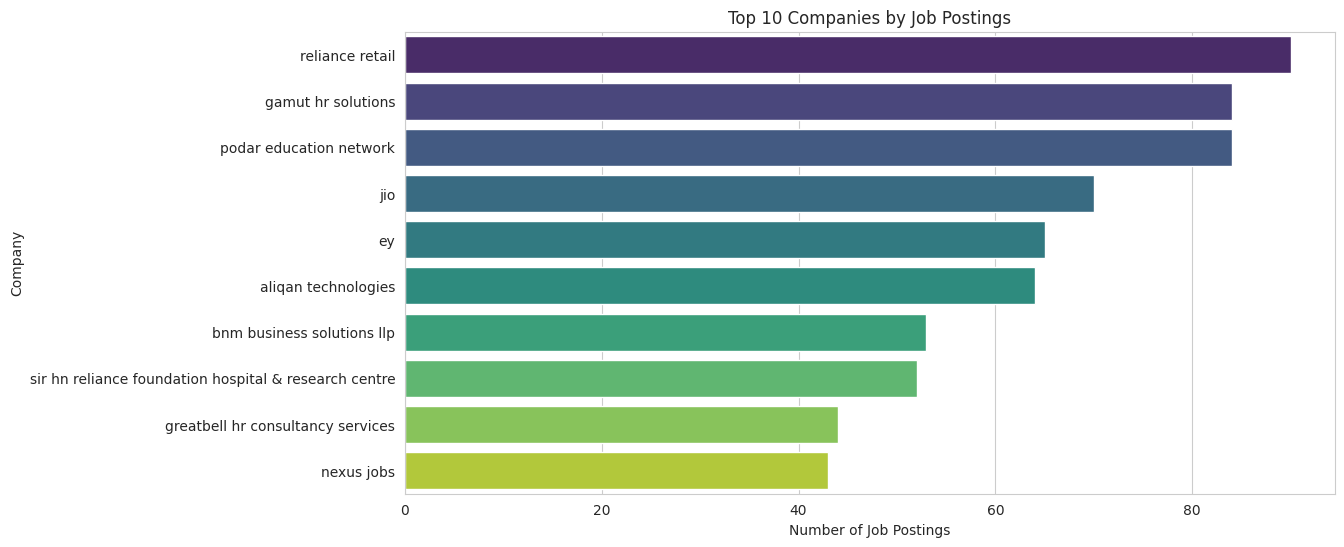

/tmp/ipython-input-1386611299.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_locations.values, y=top_locations.index, palette="magma")


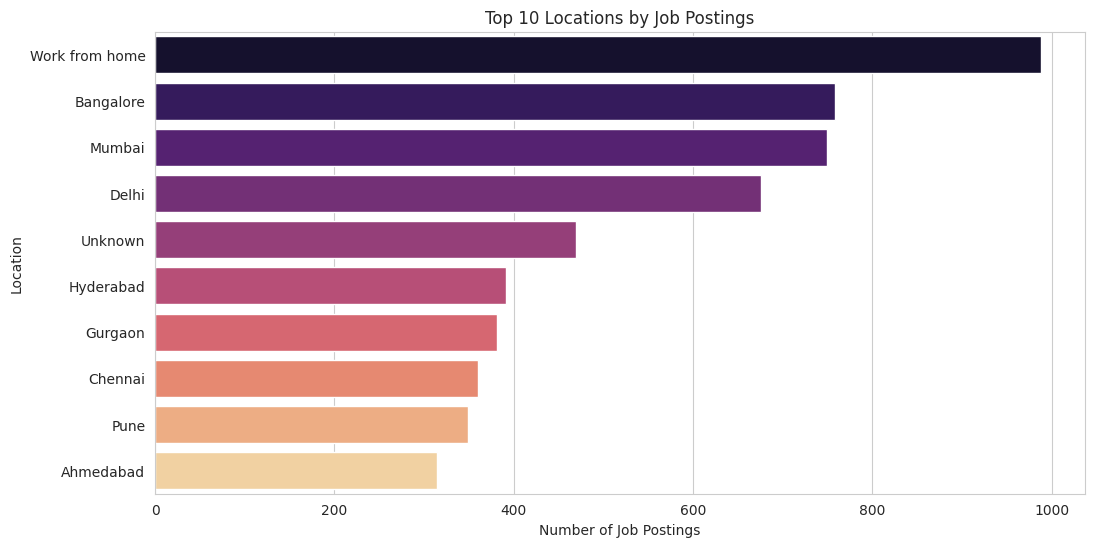

/tmp/ipython-input-1386611299.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_job_roles.values, y=top_job_roles.index, palette="coolwarm")


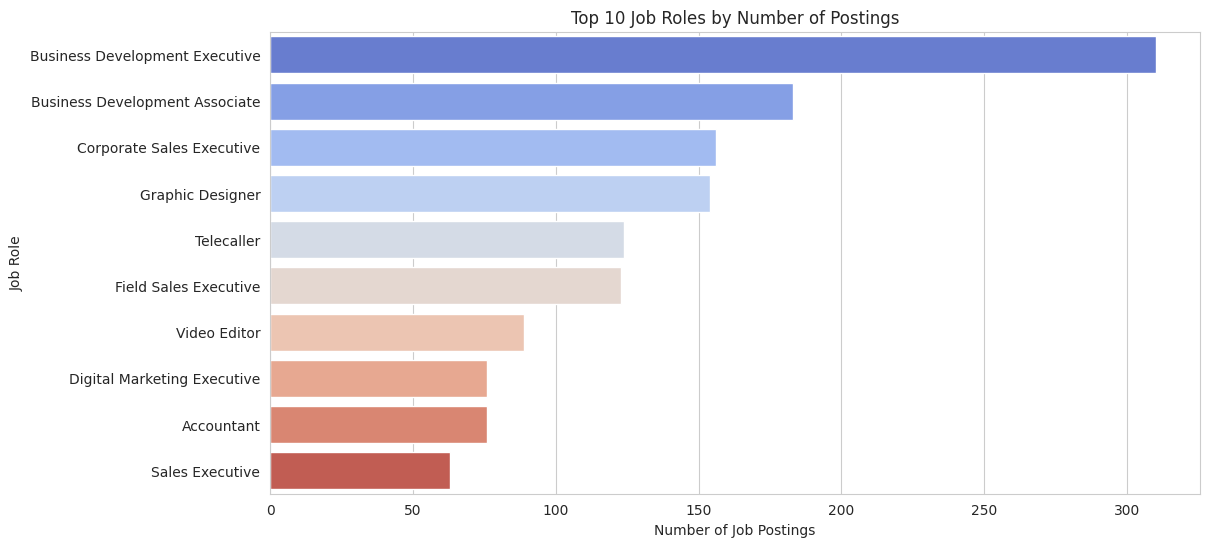

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style("whitegrid")

# ---- Top 10 Companies ----
plt.figure(figsize=(12,6))
sns.barplot(x=top_companies.values, y=top_companies.index, palette="viridis")
plt.title("Top 10 Companies by Job Postings")
plt.xlabel("Number of Job Postings")
plt.ylabel("Company")
plt.show()

# ---- Top 10 Locations ----
plt.figure(figsize=(12,6))
sns.barplot(x=top_locations.values, y=top_locations.index, palette="magma")
plt.title("Top 10 Locations by Job Postings")
plt.xlabel("Number of Job Postings")
plt.ylabel("Location")
plt.show()

# ---- Top 10 Job Roles ----
plt.figure(figsize=(12,6))
sns.barplot(x=top_job_roles.values, y=top_job_roles.index, palette="coolwarm")
plt.title("Top 10 Job Roles by Number of Postings")
plt.xlabel("Number of Job Postings")
plt.ylabel("Job Role")
plt.show()


In [ ]:
# Number of jobs
num_jobs = df.shape[0]

# Unique companies
num_companies = df['Company'].nunique()

# Unique locations
num_locations = df['Location'].nunique()

print(f"Number of jobs: {num_jobs}")
print(f"Number of unique companies: {num_companies}")
print(f"Number of unique locations: {num_locations}")


Number of jobs: 8388
Number of unique companies: 4230
Number of unique locations: 416


In [ ]:
top_locations = df['Location'].value_counts().head(10)
print("Top 10 Locations by Job Postings:\n", top_locations)


Top 10 Locations by Job Postings:
 Location
Work from home    988
Bangalore         758
Mumbai            749
Delhi             676
Unknown           469
Hyderabad         391
Gurgaon           381
Chennai           360
Pune              349
Ahmedabad         314
Name: count, dtype: int64


In [ ]:
top_companies = df['Company'].value_counts().head(10)
print("Top 10 Companies by Job Postings:\n", top_companies)


Top 10 Companies by Job Postings:
 Company
reliance retail                                          90
gamut hr solutions                                       84
podar education network                                  84
jio                                                      70
ey                                                       65
aliqan technologies                                      64
bnm business solutions llp                               53
sir hn reliance foundation hospital & research centre    52
greatbell hr consultancy services                        44
nexus jobs                                               43
Name: count, dtype: int64


In [ ]:
# Summary statistics
salary_stats = df['AvgSalary'].describe()
print("Salary Stats:\n", salary_stats)

# Min, Max
min_salary = df['AvgSalary'].min()
max_salary = df['AvgSalary'].max()
mean_salary = df['AvgSalary'].mean()


Salary Stats:
 count    8.388000e+03
mean     3.478335e+05
std      4.854386e+05
min      0.000000e+00
25%      2.000000e+05
50%      2.750000e+05
75%      4.000000e+05
max      1.950000e+07
Name: AvgSalary, dtype: float64


In [ ]:
top_job_roles = df['JOB Role'].value_counts().head(10)
print("Top 10 Job Roles:\n", top_job_roles)


Top 10 Job Roles:
 JOB Role
Business Development Executive    310
Business Development Associate    183
Corporate Sales Executive         156
Graphic Designer                  154
Telecaller                        124
Field Sales Executive             123
Video Editor                       89
Digital Marketing Executive        76
Accountant                         76
Sales Executive                    63
Name: count, dtype: int64


In [ ]:
# Average salary per top location
avg_salary_location = df.groupby('Location')['AvgSalary'].mean().sort_values(ascending=False).head(10)
print("Average Salary by Top Locations:\n", avg_salary_location)


Average Salary by Top Locations:
 Location
Begusarai     2.333333e+06
Anakapalli    1.600000e+06
Anantapur     1.494000e+06
Amritsar      9.444444e+05
Palwal        9.250000e+05
Hardoi        9.000000e+05
Gangtok       9.000000e+05
Sonbhadra     9.000000e+05
Ankleshwar    9.000000e+05
Dharmapuri    9.000000e+05
Name: AvgSalary, dtype: float64


/tmp/ipython-input-2915657508.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_companies.values, y=top_companies.index, palette="viridis")


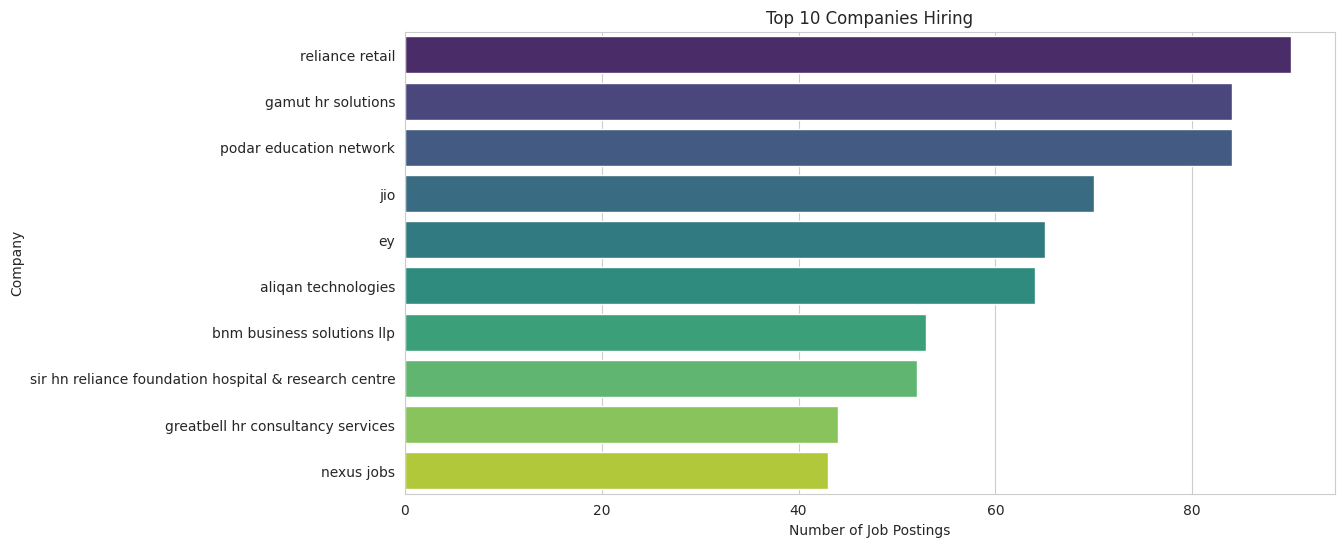

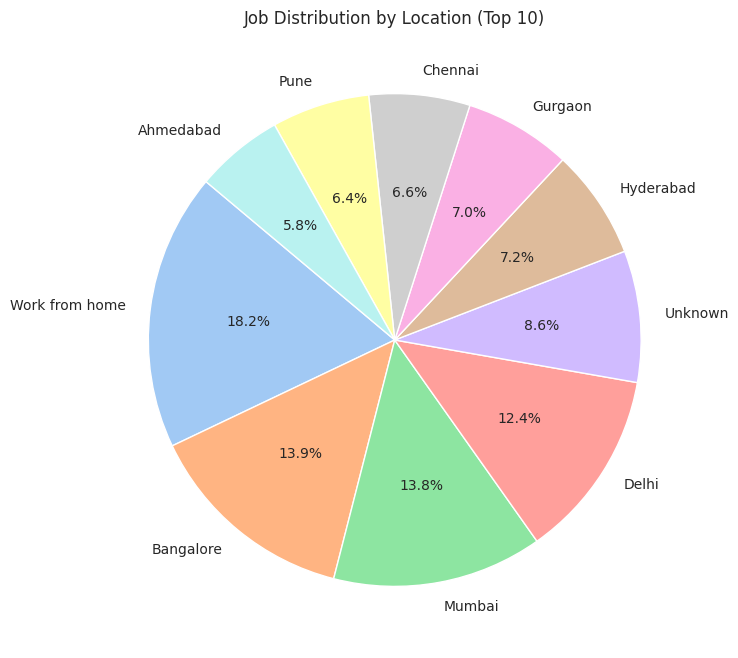

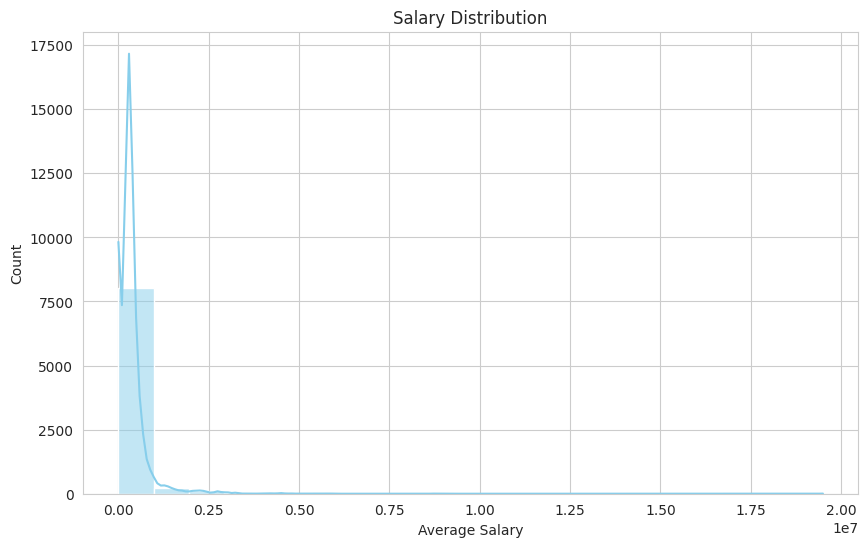

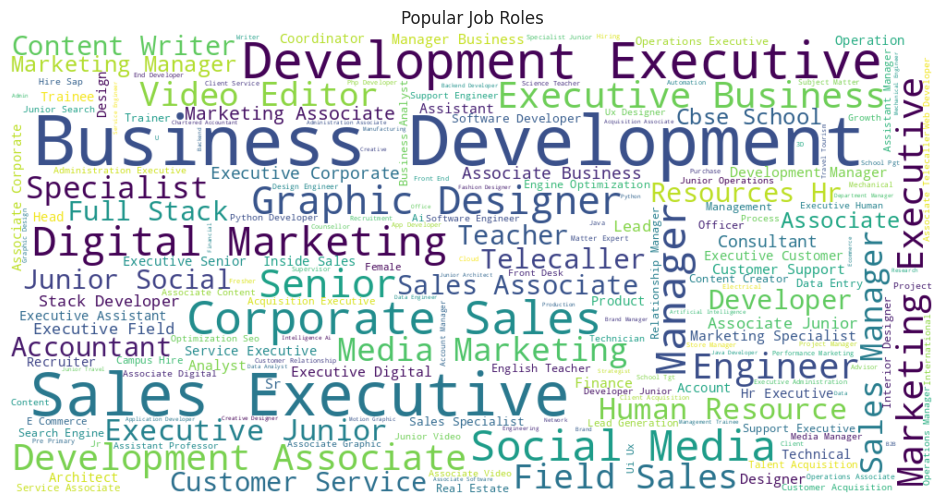

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

sns.set_style("whitegrid")

# ---- Bar Chart: Top 10 Companies ----
plt.figure(figsize=(12,6))
sns.barplot(x=top_companies.values, y=top_companies.index, palette="viridis")
plt.title("Top 10 Companies Hiring")
plt.xlabel("Number of Job Postings")
plt.ylabel("Company")
plt.show()

# ---- Pie Chart: Jobs by Location ----
plt.figure(figsize=(8,8))
plt.pie(top_locations.values, labels=top_locations.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette("pastel"))
plt.title("Job Distribution by Location (Top 10)")
plt.show()

# ---- Histogram: Salary Ranges ----
plt.figure(figsize=(10,6))
sns.histplot(df['AvgSalary'], bins=20, kde=True, color='skyblue')
plt.title("Salary Distribution")
plt.xlabel("Average Salary")
plt.ylabel("Count")
plt.show()

# ---- Word Cloud: Popular Job Roles ----
plt.figure(figsize=(12,6))
text = ' '.join(df['JOB Role'].dropna())
wordcloud = WordCloud(width=1000, height=500, background_color='white', colormap='viridis').generate(text)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Popular Job Roles")
plt.show()


In [ ]:
pip install streamlit


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 69.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 119.1 MB/s eta 0:00:00


2025-10-29 08:32:21.893 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-10-29 08:32:22.185 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2025-10-29 08:32:22.187 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-10-29 08:32:22.188 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-10-29 08:32:22.193 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-10-29 08:32:22.194 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-10-29 08:32:22.205 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-10-29 08:32:22.207 Thread 'MainThread': mi

DeltaGenerator()

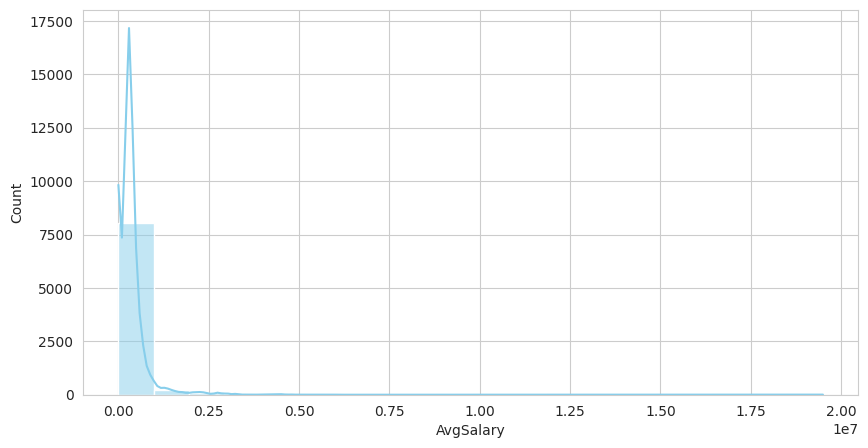

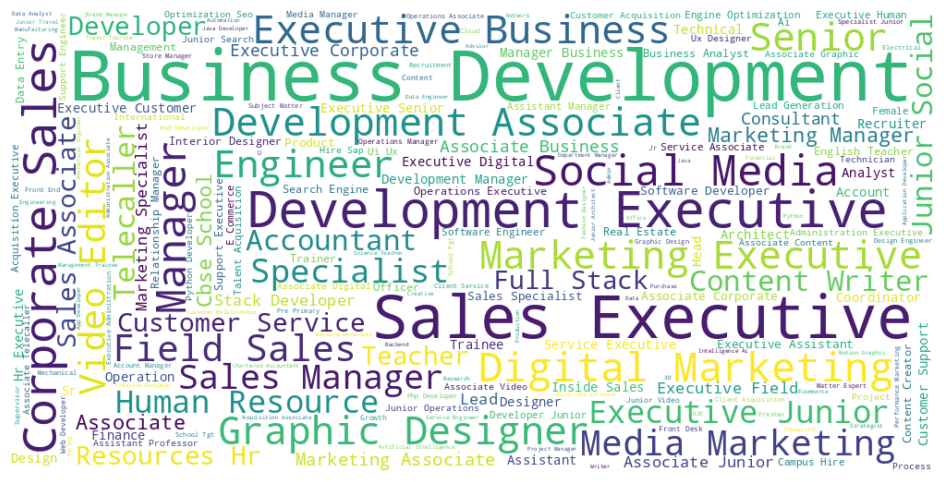

In [ ]:
import streamlit as st
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# Load dataset
df = pd.read_csv("/content/Cleaned_Internshala_Jobs.csv")

# --- Sidebar ---
st.sidebar.title("Job Dashboard Filters")
location_filter = st.sidebar.multiselect("Select Locations", options=df['Location'].unique(), default=df['Location'].unique())
company_filter = st.sidebar.multiselect("Select Companies", options=df['Company'].unique(), default=df['Company'].unique())

# Filter data
filtered_df = df[(df['Location'].isin(location_filter)) & (df['Company'].isin(company_filter))]

# --- Title ---
st.title("Job Market Dashboard")
st.markdown("Interactive dashboard of jobs, companies, locations, salaries, and job roles.")

# --- Descriptive Stats ---
st.subheader("📊 Descriptive Stats")
st.write(f"Total Jobs: {filtered_df.shape[0]}")
st.write(f"Unique Companies: {filtered_df['Company'].nunique()}")
st.write(f"Unique Locations: {filtered_df['Location'].nunique()}")

# --- Top Locations ---
st.subheader("📍 Top Locations")
top_locations = filtered_df['Location'].value_counts().head(10)
st.bar_chart(top_locations)

# --- Top Companies ---
st.subheader("🏢 Top Hiring Companies")
top_companies = filtered_df['Company'].value_counts().head(10)
st.bar_chart(top_companies)

# --- Salary Insights ---
st.subheader("💰 Salary Insights")
st.write(filtered_df['AvgSalary'].describe())

# Salary Histogram
fig, ax = plt.subplots(figsize=(10,5))
sns.histplot(filtered_df['AvgSalary'], bins=20, kde=True, color='skyblue', ax=ax)
st.pyplot(fig)

# --- Job Role Trends ---
st.subheader("🎯 Top Job Roles")
top_roles = filtered_df['JOB Role'].value_counts().head(10)
st.bar_chart(top_roles)

# --- Word Cloud ---
st.subheader("Word Cloud of Job Roles")
text = ' '.join(filtered_df['JOB Role'].dropna())
wordcloud = WordCloud(width=1000, height=500, background_color='white', colormap='viridis').generate(text)
fig_wc, ax_wc = plt.subplots(figsize=(12,6))
ax_wc.imshow(wordcloud, interpolation='bilinear')
ax_wc.axis('off')
st.pyplot(fig_wc)

# --- Salary vs Location ---
st.subheader("📈 Average Salary by Location")
avg_salary_location = filtered_df.groupby('Location')['AvgSalary'].mean().sort_values(ascending=False).head(10)
st.bar_chart(avg_salary_location)


In [ ]:
!pip install streamlit pyngrok -q


In [ ]:
!ngrok config add-authtoken "310VY60ZEUCjMf3Mh4vN46mI8th_2nRWadz18iDAnwjn48tQ7"


Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml


In [ ]:
%%writefile dashboard.py
import streamlit as st
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# Load dataset
df = pd.read_csv("/content/Cleaned_Internshala_Jobs.csv")

# --- Sidebar ---
st.sidebar.title("Job Dashboard Filters")
location_filter = st.sidebar.multiselect("Select Locations", options=df['Location'].unique(), default=df['Location'].unique())
company_filter = st.sidebar.multiselect("Select Companies", options=df['Company'].unique(), default=df['Company'].unique())

# Filter data
filtered_df = df[(df['Location'].isin(location_filter)) & (df['Company'].isin(company_filter))]

# --- Title ---
st.title("Job Market Dashboard")
st.markdown("Interactive dashboard of jobs, companies, locations, salaries, and job roles.")

# --- Descriptive Stats ---
st.subheader("📊 Descriptive Stats")
st.write(f"Total Jobs: {filtered_df.shape[0]}")
st.write(f"Unique Companies: {filtered_df['Company'].nunique()}")
st.write(f"Unique Locations: {filtered_df['Location'].nunique()}")

# --- Top Locations ---
st.subheader("📍 Top Locations")
top_locations = filtered_df['Location'].value_counts().head(10)
st.bar_chart(top_locations)

# --- Top Companies ---
st.subheader("🏢 Top Hiring Companies")
top_companies = filtered_df['Company'].value_counts().head(10)
st.bar_chart(top_companies)

# --- Salary Insights ---
st.subheader("💰 Salary Insights")
st.write(filtered_df['AvgSalary'].describe())

# Salary Histogram
fig, ax = plt.subplots(figsize=(10,5))
sns.histplot(filtered_df['AvgSalary'], bins=20, kde=True, color='skyblue', ax=ax)
st.pyplot(fig)

# --- Job Role Trends ---
st.subheader("🎯 Top Job Roles")
top_roles = filtered_df['JOB Role'].value_counts().head(10)
st.bar_chart(top_roles)

# --- Word Cloud ---
st.subheader("Word Cloud of Job Roles")
text = ' '.join(filtered_df['JOB Role'].dropna())
wordcloud = WordCloud(width=1000, height=500, background_color='white', colormap='viridis').generate(text)
fig_wc, ax_wc = plt.subplots(figsize=(12,6))
ax_wc.imshow(wordcloud, interpolation='bilinear')
ax_wc.axis('off')
st.pyplot(fig_wc)

# --- Salary vs Location ---
st.subheader("📈 Average Salary by Location")
avg_salary_location = filtered_df.groupby('Location')['AvgSalary'].mean().sort_values(ascending=False).head(10)
st.bar_chart(avg_salary_location)


Writing dashboard.py


In [ ]:
!streamlit run dashboard.py --server.port 8501 &>/dev/null&


In [ ]:
from pyngrok import ngrok

# Kill any existing tunnels
ngrok.kill()

# Connect port 8501
public_url = ngrok.connect(8501)
print("Streamlit URL:", public_url)


Streamlit URL: NgrokTunnel: "https://9f36aebe1cfc.ngrok-free.app" -> "http://localhost:8501"


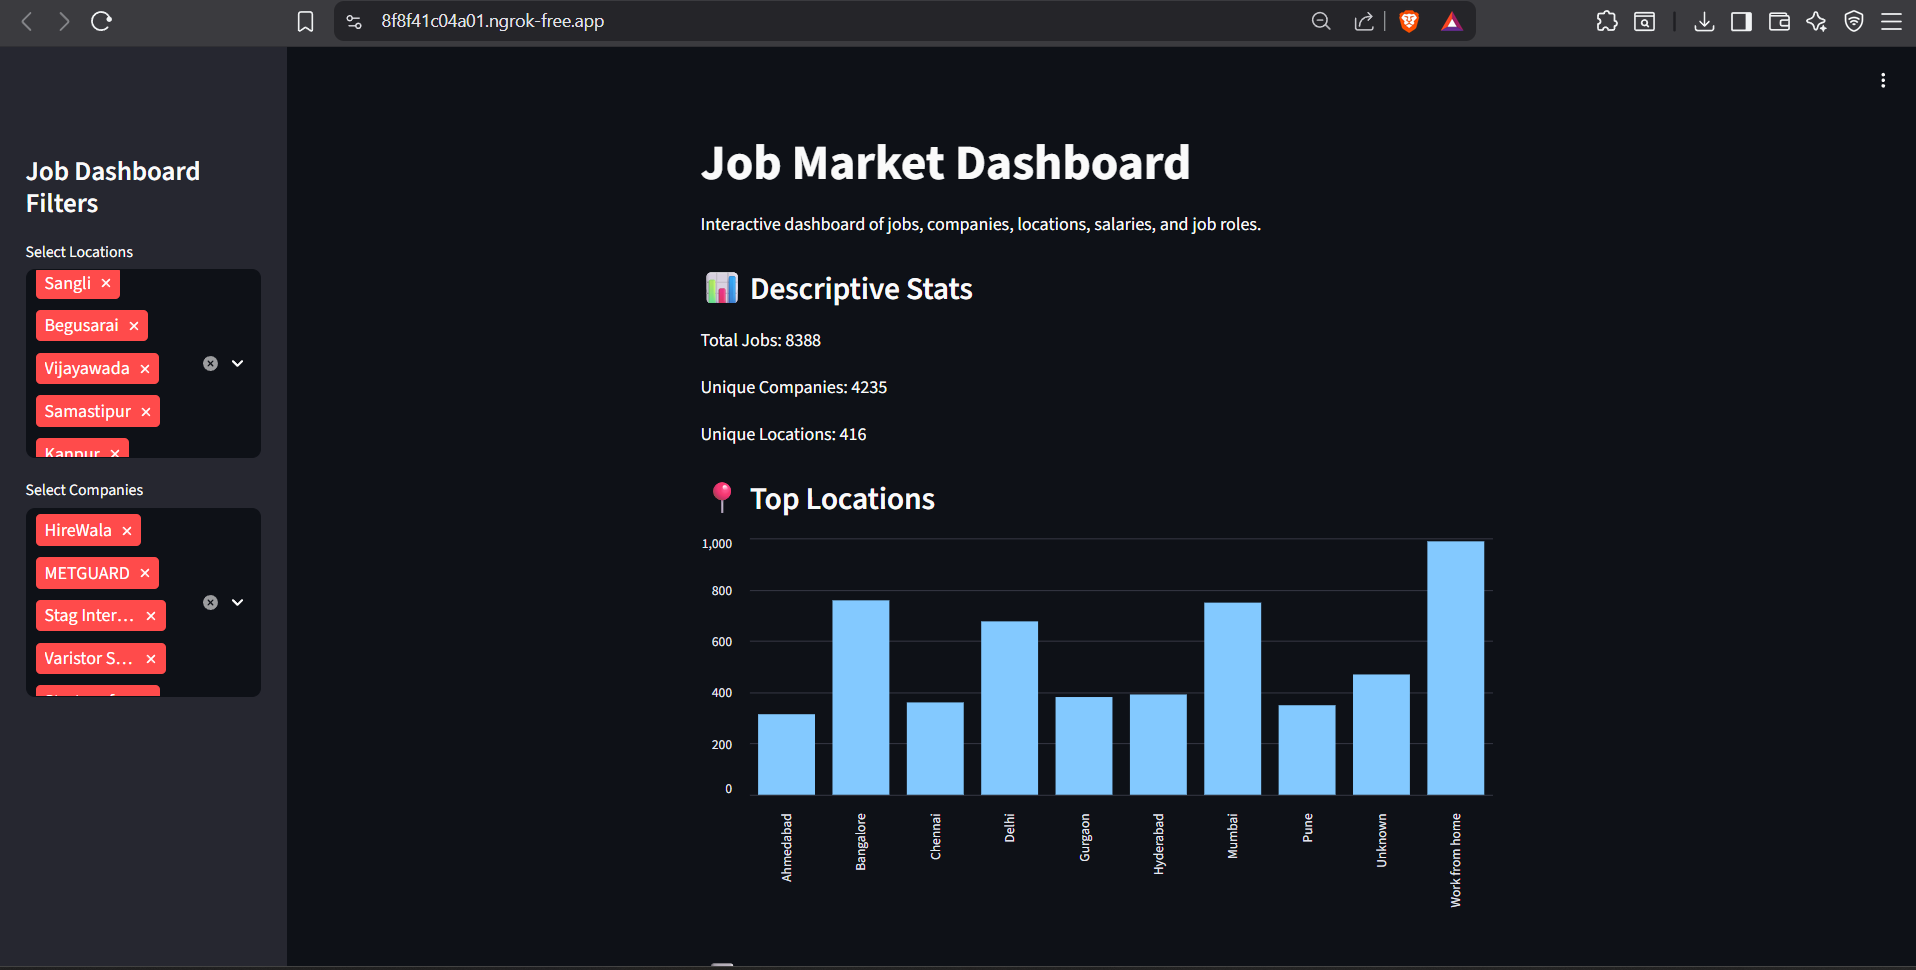

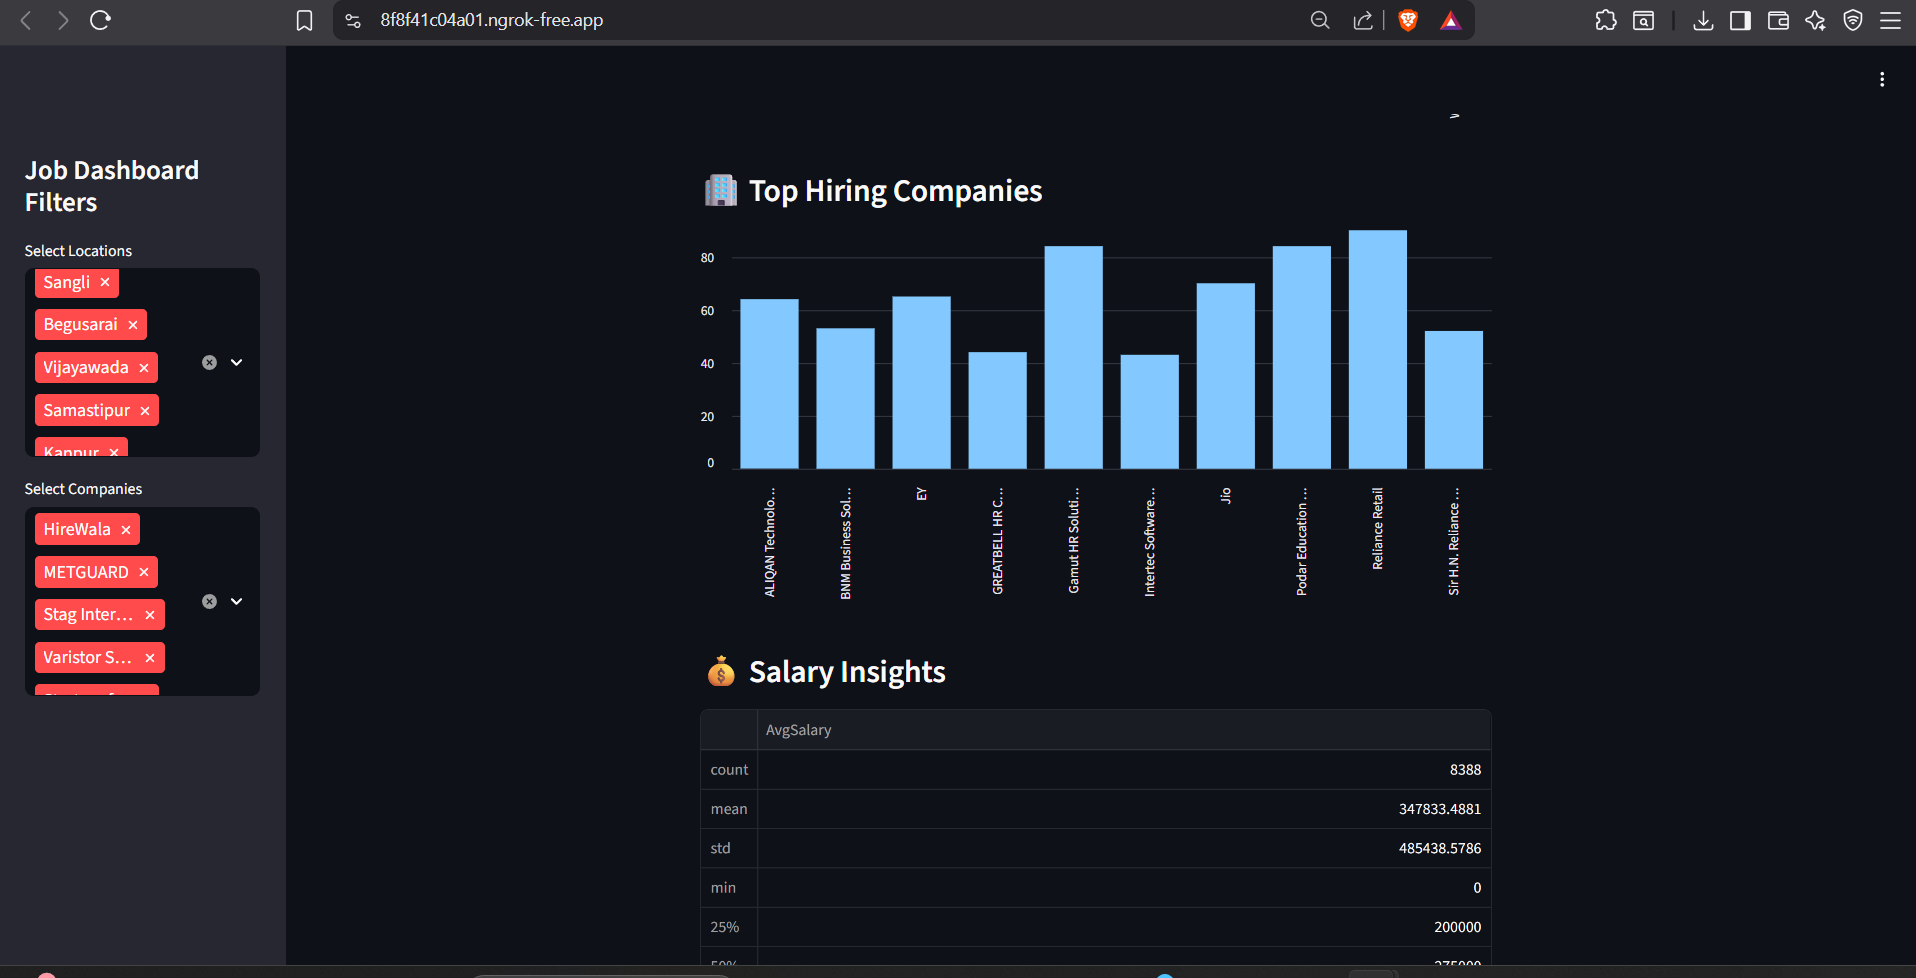

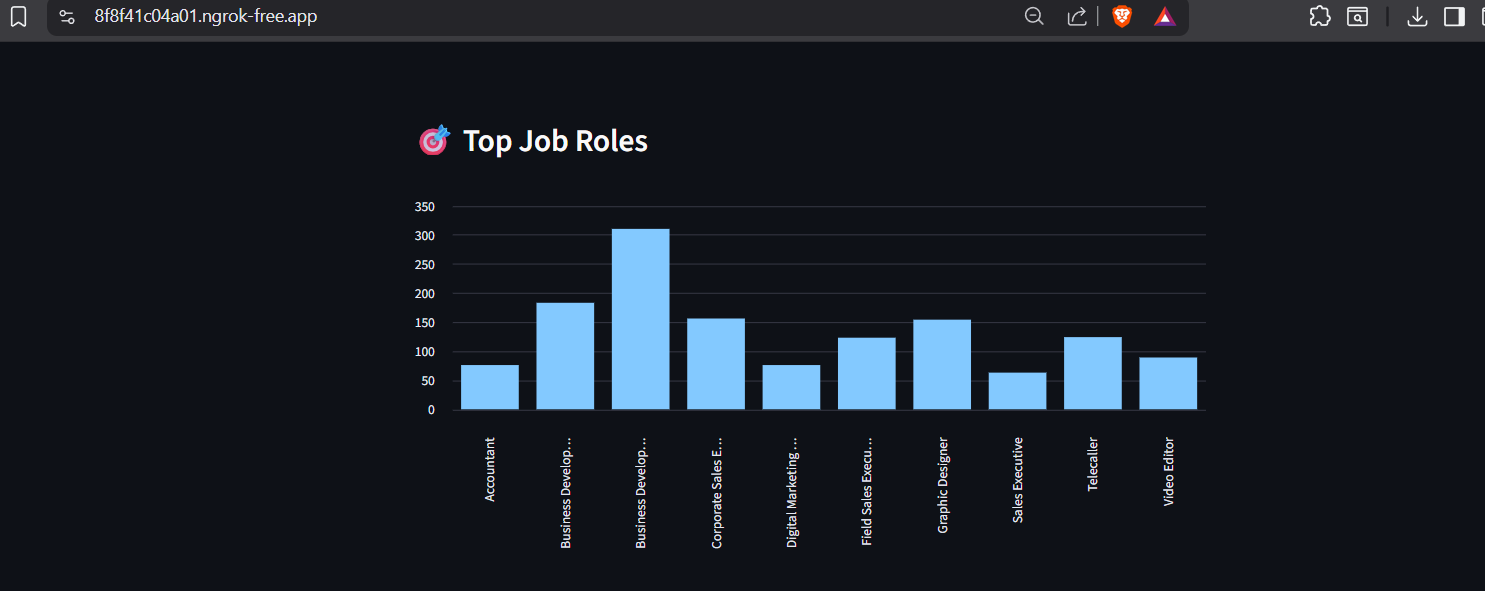

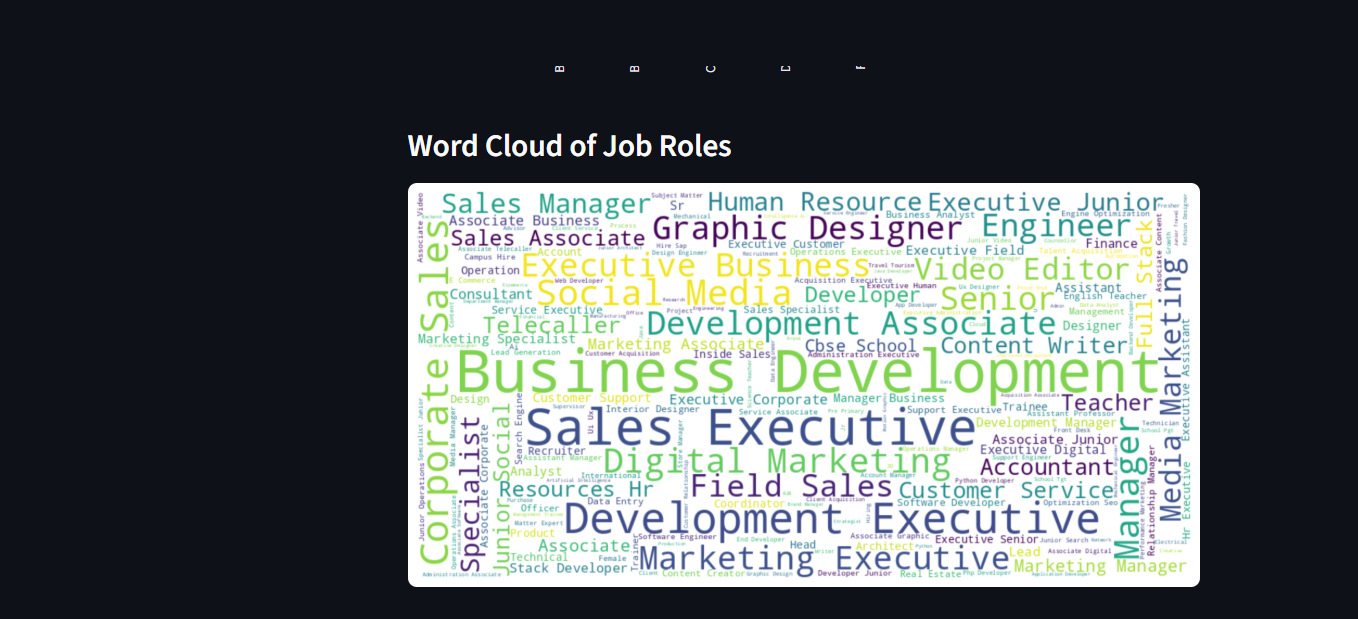

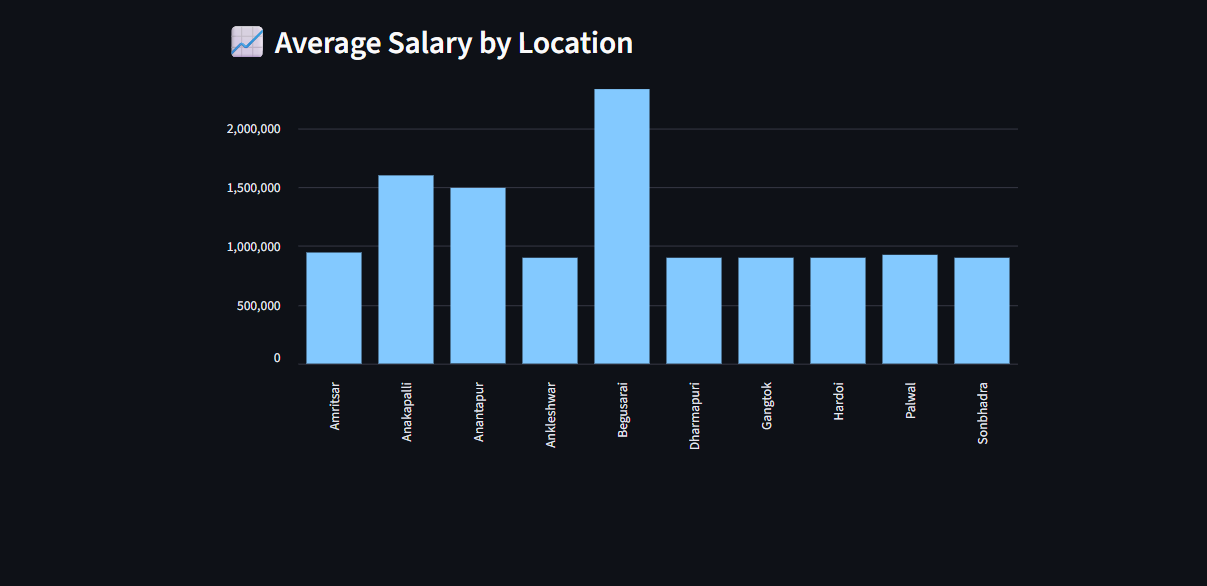